In [1]:
import pandas as pd

c:\Users\sk888\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\sk888\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [15]:
df = pd.read_csv(r"c:\Users\sk888\Downloads\pharma\pharma-data.csv")


data check


In [16]:
print(df.head())

              Distributor                         Customer Name     City  \
0  Gottlieb-Cruickshank                 Zieme, Doyle and Kunze    Lublin   
1  Gottlieb-Cruickshank                              Feest PLC   Świecie   
2  Gottlieb-Cruickshank    Medhurst-Beer Pharmaceutical Limited   Rybnik   
3  Gottlieb-Cruickshank                   Barton Ltd Pharma Plc  Czeladź   
4  Gottlieb-Cruickshank                    Keeling LLC Pharmacy  Olsztyn   

  Country  Latitude  Longitude   Channel  Sub-channel            Product Name  \
0  Poland   51.2333    22.5667  Hospital      Private              Topipizole   
1  Poland   53.4167    18.4333  Pharmacy       Retail            Choriotrisin   
2  Poland   50.0833    18.5000  Pharmacy  Institution               Acantaine   
3  Poland   50.3333    19.0833  Hospital      Private    Lioletine Refliruvax   
4  Poland   53.7800    20.4942  Pharmacy       Retail  Oxymotroban Fexoformin   

      Product Class  Quantity  Price   Sales    Month  Y

In [17]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254082 entries, 0 to 254081
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Distributor        254082 non-null  object 
 1   Customer Name      254082 non-null  object 
 2   City               254082 non-null  object 
 3   Country            254082 non-null  object 
 4   Latitude           254082 non-null  float64
 5   Longitude          254082 non-null  float64
 6   Channel            254082 non-null  object 
 7   Sub-channel        254082 non-null  object 
 8   Product Name       254082 non-null  object 
 9   Product Class      254082 non-null  object 
 10  Quantity           254082 non-null  float64
 11  Price              254082 non-null  int64  
 12  Sales              254082 non-null  float64
 13  Month              254082 non-null  object 
 14  Year               254082 non-null  int64  
 15  Name of Sales Rep  254082 non-null  object 
 16  Ma

data cleaning


In [18]:
df.drop_duplicates(inplace=True)

In [22]:
df.fillna(method='ffill',inplace=True)

C:\Users\sk888\AppData\Local\Temp\ipykernel_10292\4116506308.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill',inplace=True)


In [24]:
df['Profit'] = df['Sales'] - (df['Quantity'] * df['Price'])

#Which Cities Generate Highest Sales


In [25]:
df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)

City
Butzbach          9.356178e+07
Baesweiler        6.489050e+07
Cuxhaven          5.600668e+07
Friedberg         5.218363e+07
Altenburg         5.088532e+07
Emsdetten         4.593901e+07
Bottrop           4.445462e+07
Freising          4.377938e+07
Trier             4.349563e+07
Castrop-Rauxel    4.206666e+07
Name: Sales, dtype: float64

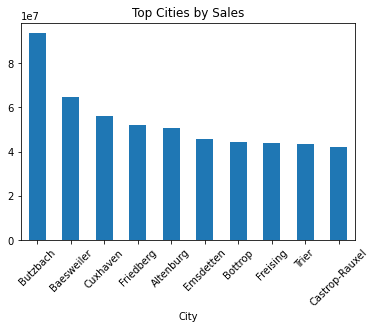

In [40]:
df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Cities by Sales")
plt.xticks(rotation=45)
plt.show()

#Which Customers Bring Most Revenue?


In [26]:
df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

Customer Name
Mraz-Kutch Pharma Plc                                    9.356178e+07
Parker, Green and Emmerich Pharma Plc                    6.489050e+07
Zemlak-Witting                                           5.600668e+07
Moen, Murazik and Smith Pharm                            5.088532e+07
Mills Inc Pharmaceutical Ltd                             4.593901e+07
Streich PLC                                              4.445462e+07
Gleichner, Bahringer and Morar Pharmaceutical Limited    4.377938e+07
Reichel Inc                                              4.349563e+07
Romaguera, Moen and Hagenes Pharmacy                     4.206666e+07
Torphy, Pfeffer and Jakubowski Pharm                     4.151422e+07
Name: Sales, dtype: float64

which sales reps perform best


In [27]:
df.groupby('Name of Sales Rep')['Sales'].sum().sort_values(ascending=False).head(10)

Name of Sales Rep
Jimmy Grey          9.859700e+08
Abigail Thompson    9.810570e+08
Sheila Stones       9.582039e+08
Daniel Gates        9.506586e+08
Anne Wu             9.201683e+08
Morris Garcia       9.011955e+08
Stella Given        8.883409e+08
Jessica Smith       8.816976e+08
Steve Pepple        8.754500e+08
Mary Gerrard        8.752669e+08
Name: Sales, dtype: float64

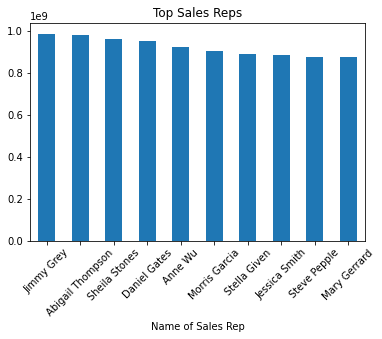

In [43]:
df.groupby('Name of Sales Rep')['Sales'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Sales Reps")
plt.xticks(rotation=45)
plt.show()

which product give highest profit


In [28]:
df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)

Product Name
Choriotrisin             0.000249
Secrelazine Insonamic    0.000036
Araxetine                0.000030
Decidenu Galantrigine    0.000027
Diazemid Felcept         0.000026
Thalilamide              0.000021
Interfedox Pilobamol     0.000008
Ketamara Evogel          0.000008
Presetron                0.000008
Pulmodiol Adalaxime      0.000003
Name: Profit, dtype: float64

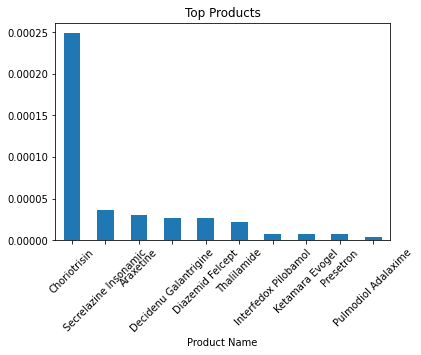

In [42]:
df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Products")
plt.xticks(rotation=45)
plt.show()


which product class performs best


In [30]:
df.groupby('Product Class')['Sales'].sum().sort_values(ascending=False)

Product Class
Analgesics          2.371510e+09
Antiseptics         2.237520e+09
Mood Stabilizers    2.058910e+09
Antipiretics        1.883306e+09
Antibiotics         1.750277e+09
Antimalarial        1.497455e+09
Name: Sales, dtype: float64

which channel gives more sales


In [31]:
df.groupby('Channel')['Sales'].sum()

Channel
Hospital    5.580675e+09
Pharmacy    6.218303e+09
Name: Sales, dtype: float64

monthly sales trend


In [33]:
df.groupby('Month')['Sales'].sum()

Month
April        8.000338e+08
August       1.186627e+09
December     9.750071e+08
February     9.721298e+08
January      6.741911e+08
July         1.042537e+09
June         1.064029e+09
March        1.108802e+09
May          8.651872e+08
November     1.108803e+09
October      9.716472e+08
September    1.029984e+09
Name: Sales, dtype: float64

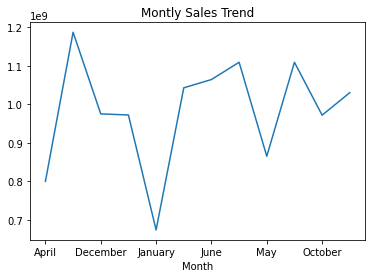

In [41]:
df.groupby('Month')['Sales'].sum().plot()
plt.title("Montly Sales Trend")
plt.show()


year-wise growth


In [34]:
df.groupby('Year')['Sales'].sum()

Year
2017    2.701480e+09
2018    3.506892e+09
2019    2.930933e+09
2020    2.659672e+09
Name: Sales, dtype: float64

loss making products


In [37]:
df[df['Profit']<0]['Product Name'].value_counts().head(10)

Product Name
Amcibax Amcikeran       2
Proderal                1
Tiaracil                1
Diprolimus              1
Halciramine             1
Interfedox Pilobamol    1
Sevotrana Tiafoxin      1
Trazobalamin            1
Penitrana               1
Cyclovital              1
Name: count, dtype: int64

sales team performance


In [38]:
df.groupby('Sales Team')['Sales'].sum()

Sales Team
Alfa       2.580969e+09
Bravo      2.757702e+09
Charlie    2.824970e+09
Delta      3.635337e+09
Name: Sales, dtype: float64